# BANANA

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### PARAMS

In [ ]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Proved highly effective for microstructure
Z_WINDOW = 100              # Keep: Captures the fast bid/ask bounces
ENTRY_Z = 1.25              # Keep: Solid entry point with tight spreads
EXIT_Z = -0.25              # Keep: Excellent momentum capture past the mean
AR_LIMIT = 0.995            # CHANGED: Loosened from 0.95
DANGER_THRESHOLD = 0.90     # CHANGED: Loosened from 0.50

### DATA

In [3]:
months = [
    # "201901", "201902", "201903", "201904", "201905", "201906",
    # "201907", "201908", "201909", "201910", "201911", "201912",
    # "202001", "202002", "202003", "202004", "202005", "202006",
    # "202007", "202008", "202009", "202010", "202011", "202012",
    # "202101", "202102", "202103", "202104", "202105", "202106",
    # "202107", "202108", "202109", "202110", "202111", "202112",
    # "202201", "202202", "202203", "202204", "202205", "202206",
    # "202207", "202208", "202209", "202210", "202211", "202212",
    # "202301", "202302", "202303", "202304", "202305", "202306",
    # "202307", "202308", "202309", "202310", "202311", "202312",
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 22196 rows
                                   Asset_A    Bid_A    Ask_A   Asset_B  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00  0.681490  0.68144  0.68154  0.630575   
2024-01-02 10:18:46.229000+00:00  0.681295  0.68123  0.68136  0.630540   
2024-01-02 10:25:10.405000+00:00  0.681155  0.68110  0.68121  0.630510   

                                    Bid_B    Ask_B     Log_A     Log_B  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00  0.63051  0.63064 -0.383474 -0.461123   
2024-01-02 10:18:46.229000+00:00  0.63050  0.63058 -0.383760 -0.461179   
2024-01-02 10:25:10.405000+00:00  0.63046  0.63056 -0.383965 -0.461226   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2024-01-02 10:12:52.660000+00:00 -0.000755 -0.000396          0.733686   
2024-01-02 10:18:46

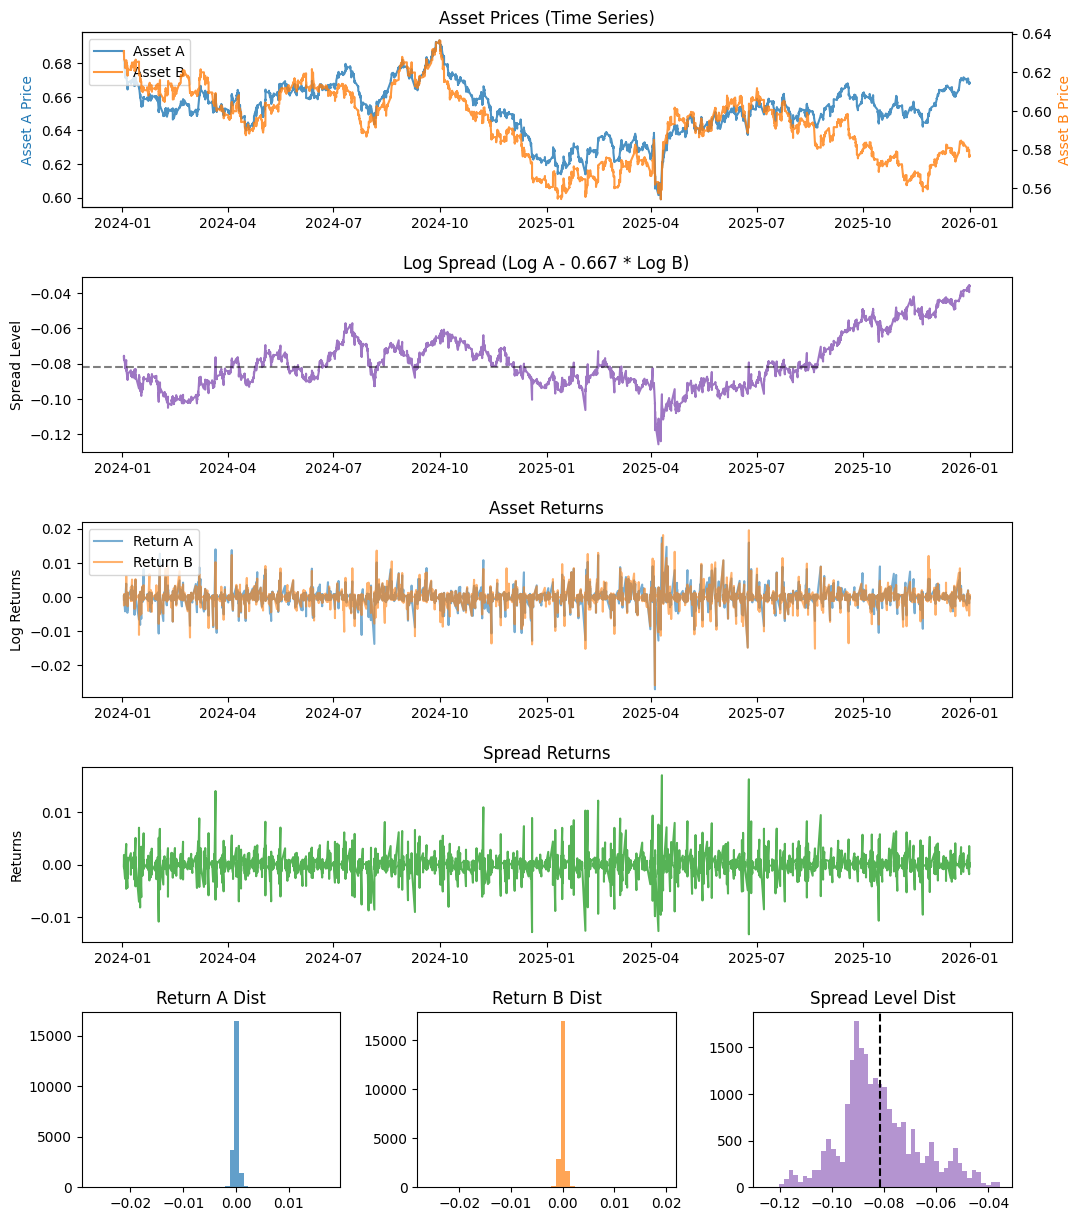

In [4]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(10, 14))
df = builder.build(my_files)

print(df.head(3))
print("\nColumns:", list(df.columns))
print(f"Median half-spread (bps) — A: {df['HalfSpread_A_bps'].median():.2f} | "
      f"B: {df['HalfSpread_B_bps'].median():.2f}")

# Call the new diagnostic plotter after the data is built
builder.plot_diagnostics()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.9143 | half-life=589.4 | β=0.6668

Rolling (2000-bar, step 200, n=101):
  p<0.05: 3.0% | p<0.10: 5.9%
  half-life: 60.8 (IQR 36–85)
  β: 0.7075 ±0.2800 [-0.3099, 1.3666]


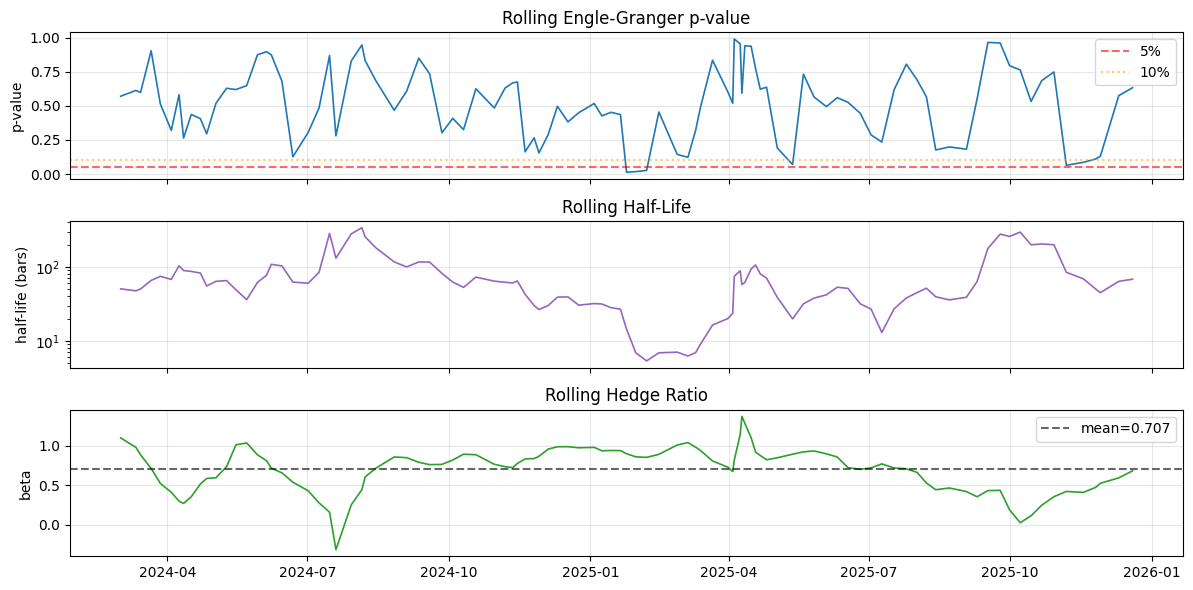

In [5]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [6]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [7]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.5712 | AR: 0.9597
[2024-02-27] Beta: 0.6073 | AR: 0.9665
[2024-03-12] Beta: 1.2336 | AR: 0.9726
[2024-03-26] Beta: 0.6611 | AR: 0.9444
[2024-04-09] Beta: 1.2298 | AR: 0.9173
[2024-04-23] Beta: 0.9211 | AR: 0.9550
[2024-05-07] Beta: 0.9912 | AR: 0.9508
[2024-05-21] Beta: 0.5914 | AR: 0.9400
[2024-06-04] Beta: 0.8412 | AR: 0.9454
[2024-06-18] Beta: 0.9009 | AR: 0.9732
[2024-07-02] Beta: -0.0650 | AR: 0.9814
[2024-07-16] Beta: -0.0141 | AR: 0.9677
[2024-07-30] Beta: 0.9509 | AR: 0.9752
[2024-08-13] Beta: 1.0605 | AR: 0.9793
[2024-08-27] Beta: 0.7465 | AR: 0.9842
[2024-09-10] Beta: 1.0100 | AR: 0.9657
[2024-09-24] Beta: 1.2542 | AR: 0.9515
[2024-10-08] Beta: 0.5803 | AR: 0.9275
[2024-10-22] Beta: 0.8069 | AR: 0.9416
[2024-11-05] Beta: 1.3379 | AR: 0.8963
[2024-11-19] Beta: 0.8278 | AR: 0.9316
[2024-12-03] Beta: -0.0532 | AR: 0.9539
[2024-12-17] Beta: 0.7409 | AR: 0.9679
[2025-01-02] Beta: 0.8414 | AR: 0.9

In [8]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)


                      QUANTITATIVE STRATEGY TEARSHEET                      

--- FINANCIAL METRICS ---
Total Return (bps)             | 5672.72      | 3284.26      | 1880.74      |
Annual Return (bps)            | 2923.37      | 1692.50      | 969.22       |
Annual Volatility (bps)        | 767.62       | 560.04       | 518.95       |
Max Drawdown (bps)             | -192.10      | -186.50      | -199.25      |
Sharpe Ratio                   | 3.81         | 3.02         | 1.87         |
Sortino Ratio                  | 4.74         | 2.82         | 1.59         |
Calmar Ratio                   | 15.22        | 9.08         | 4.86         |
Gross Profit (bps)             | 34322.44     | 18179.87     | 16154.09     |
Gross Loss (bps)               | 28649.72     | 14895.62     | 14273.35     |
Profit Factor                  | 1.20         | 1.22         | 1.13         |

--- STATISTICAL METRICS ---
Win Rate                       | 49.56%       | 49.41%       | 49.44%       |
Number of

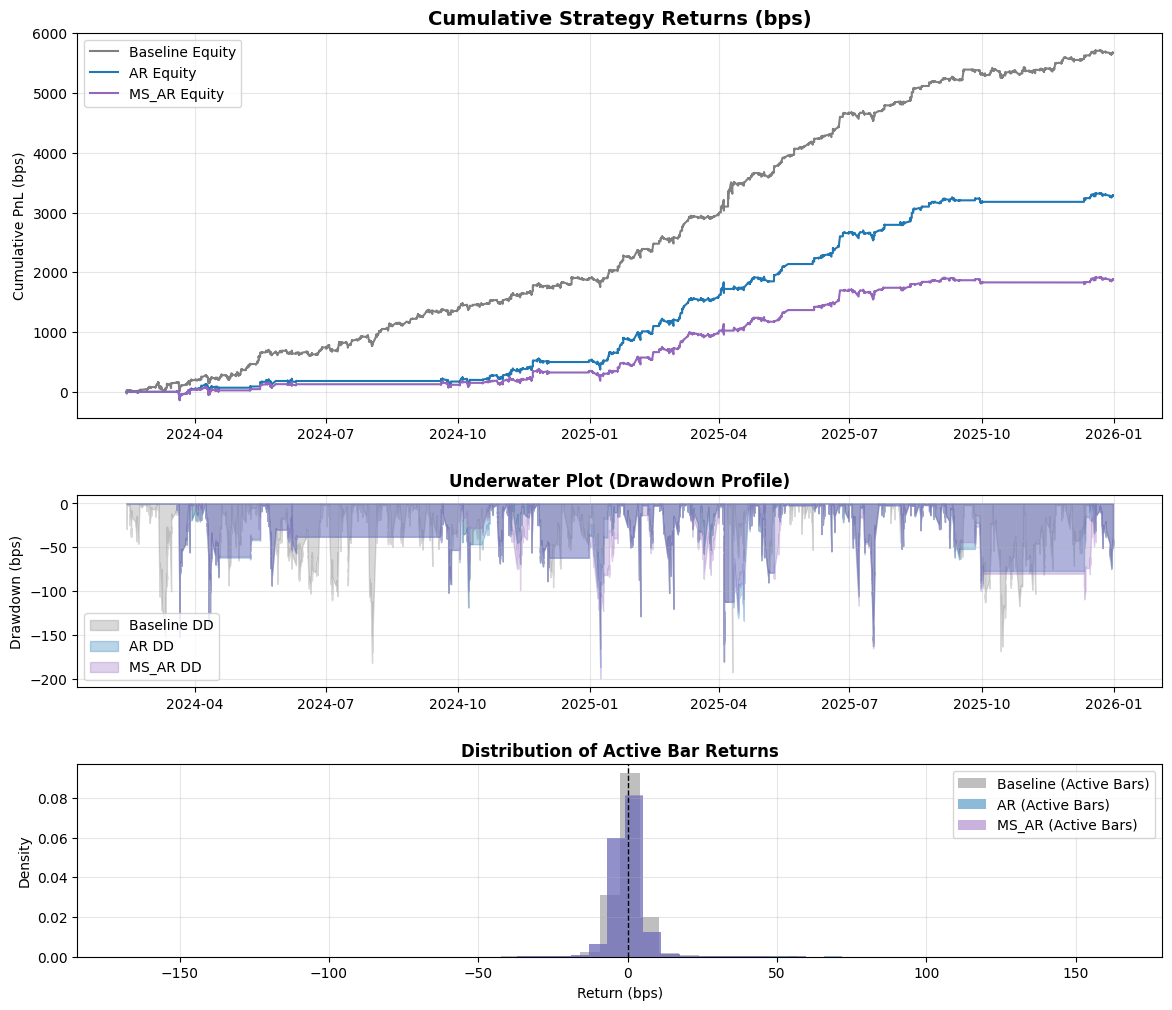

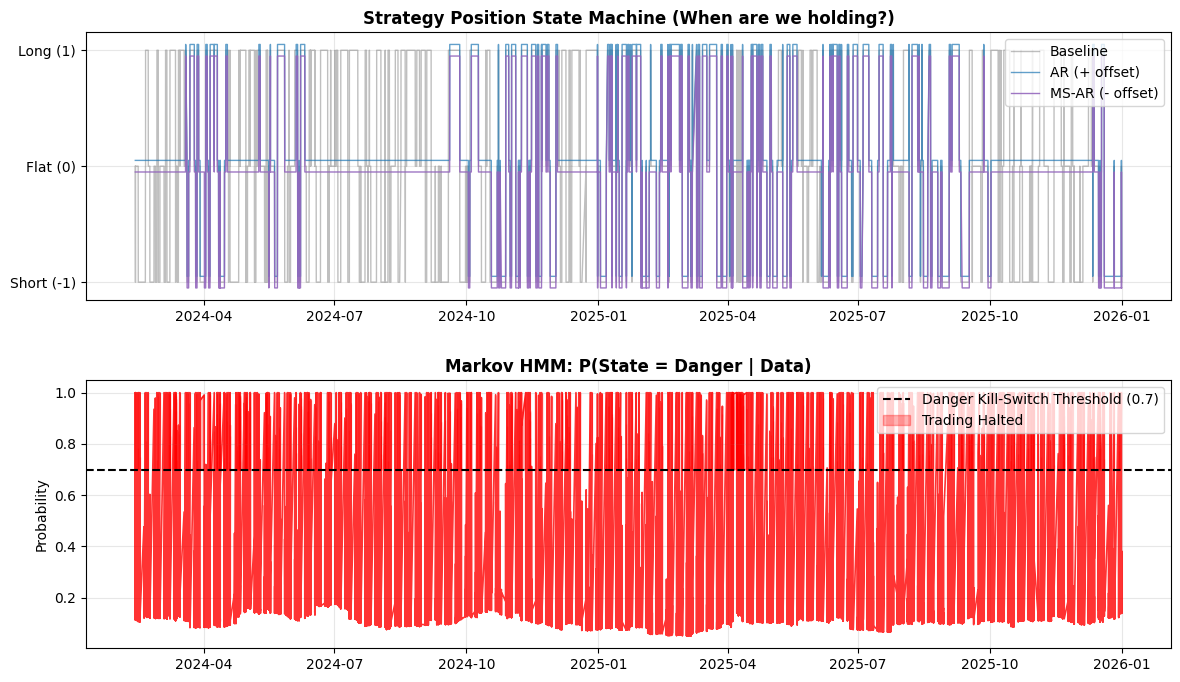

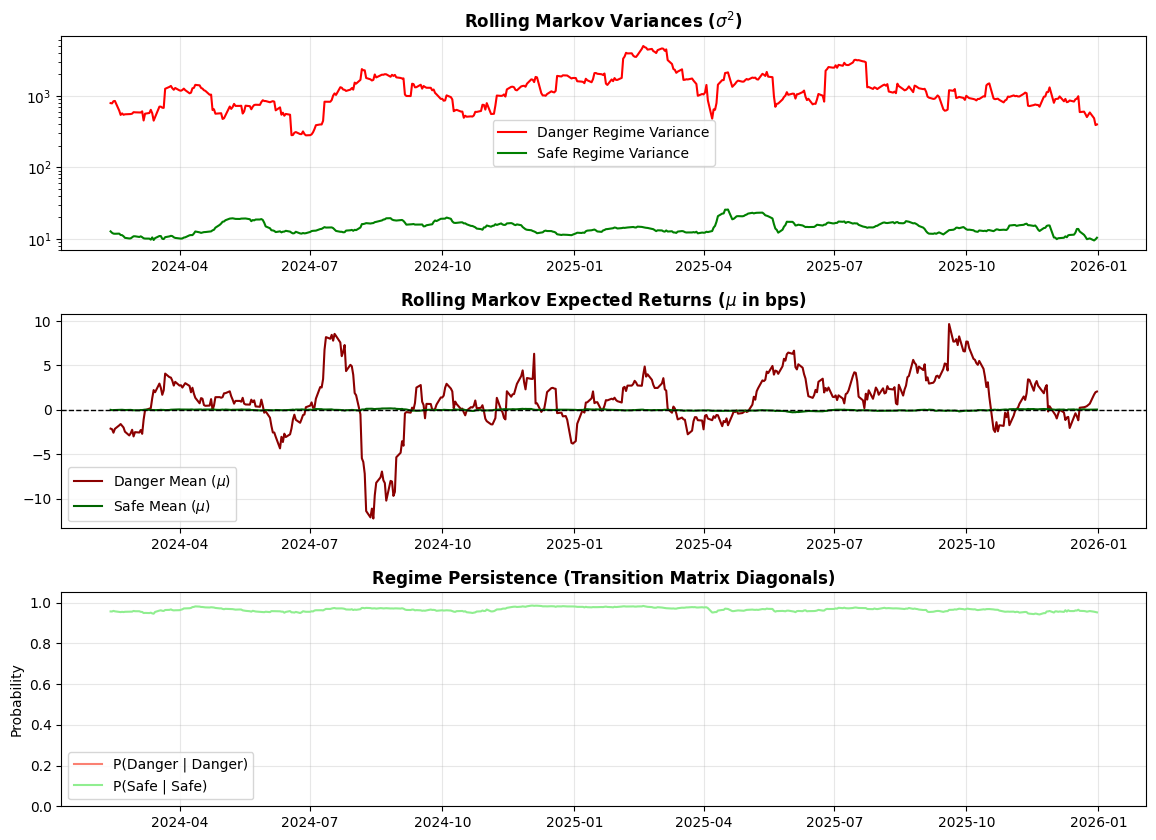

In [9]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()